# Линейная модель

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Задание 1

Из случайных значений формируется выборка $x$ и $y$ в соответствии с формулой: $y_i=w_0+w_1\cdot x_1 + \epsilon_1,\ i=1,2,...,n $. 
- $w_0$, $w_1$ – весовые коэффициенты; 
- $x_i$ – аргумент; 
- $\epsilon_i$ – случайная величина с нулевым мат.ожиданием и некоторой постоянной дисперсией.

Значение $y_i$ прогнозируется с помощью следующей параметрической модели: $a(x,w) = w_0 + w_1 \cdot x$. 
- $w_0=0.5$;
- $w_1=-0.3$; 

In [2]:
np.random.seed(0)
x = np.arange(-1.0, 1.0, 0.1)                           # Аргумент [-1; 1] с шагом 0.1
w = [0.5, -0.2]                                         # Веса модели
model_a = lambda m_x, m_w: (m_w[0] + m_w[1] * m_x)      # Модель
loss = lambda ax, y: (ax - y) ** 2                      # Квадратическая функция потерь

y = model_a(x, w) + np.random.normal(0, 0.1, len(x))    # Целевые значения: модель + случайный шум
y

array([0.87640523, 0.72001572, 0.7578738 , 0.86408932, 0.8067558 ,
       0.50227221, 0.67500884, 0.54486428, 0.52967811, 0.56105985,
       0.51440436, 0.62542735, 0.53610377, 0.4521675 , 0.46438632,
       0.43336743, 0.52940791, 0.33948417, 0.37130677, 0.23459043])

__Задание.__ Используя квадратическую функцию потерь $loss(a, y_i)=(a(x_i,w)-y_i)^2$ вычислите значение среднего эмпирического риска $Q(a, X)$ по формуле $Q(a,X)=\frac{1}{n} \cdot \sum_{i=1}^{n}loss(a,y_i)$

In [3]:
y_predicted = model_a(x, w)                             # Предсказываем y моделью
mse = np.mean(loss(y_predicted, y))                     # Вычисляем Mean Squared Error

MSE: 0.010469526728196498


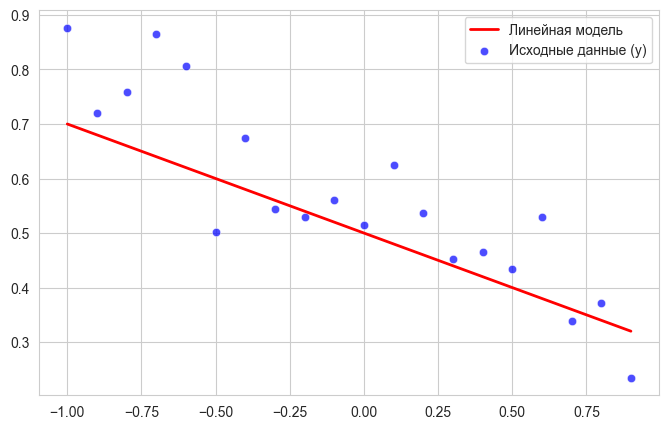

In [29]:
print(f"MSE: {mse}")
plt.figure(figsize=(8, 5))
sns.lineplot(x=x, y=y_predicted, color="red", label="Линейная модель", linewidth=2)
sns.scatterplot(x=x, y=y, color="blue", label="Исходные данные (y)", alpha=0.7);

### Задание 2

Необходимо вычислить коэффициенты $w$ модели: $a(x,w) = w_0 + w_1 \cdot x$. 

Сформируйте обучающую выборку $X$ в виде матрицы:

$$
X =
\begin{pmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{pmatrix}
$$

И вычислите коэффициенты $w$, используя следующий функционал качества (средний эмпирический риск при квадратической функции потерь):

$$
Q(a, X) = \frac{1}{n} \cdot (X \cdot w - Y)^2
$$

Дифференцируем выражение по вектору $w$, получаем:

$$
\frac{\partial Q(a, X)}{\partial w} = \frac{2}{n} \cdot X^T \cdot (X \cdot w - Y) = 0
$$

Находим вектор $w$:

$$
w = (X^T \cdot X)^{-1} \cdot X^T \cdot Y
$$

Каждый коэффициент должен быть доступен через переменную $w$ по соответствующему индексу:

$$
w[0] = w_0; \, w[1] = w_1
$$

In [5]:
np.random.seed(0) 
x = np.arange(-1.0, 1.0, 0.1)                           # Аргумент [-1; 1] с шагом 0.1
model_a = lambda xx, ww: (ww[0] + ww[1] * xx)           # Модель
Y = -5.2 + 0.7 * x + np.random.normal(0, 0.1, len(x))   # Вектор целевых значений

In [10]:
# 1. Создаем матрицу X с единичным столбцом для w0 и столбцом x для w1
X = np.vstack((np.ones_like(x), x)).T

In [33]:
# 2. Вычисляем веса W по формуле (X^T X)^(-1) X^T Y
XT = X.T  # Транспонированная матрица X
w = np.linalg.inv(XT @ X) @ XT @ Y  # Вычисление весов

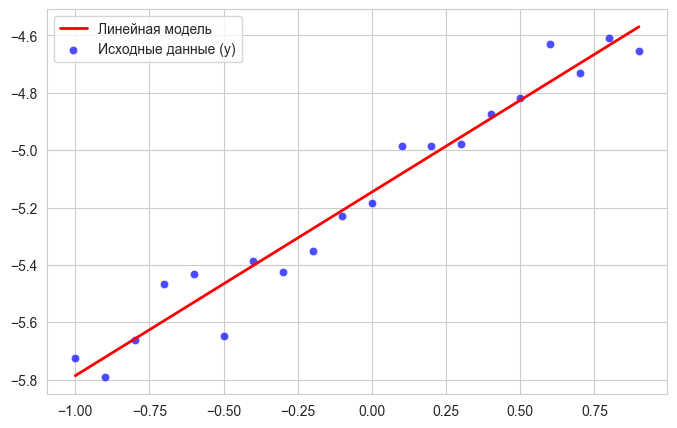

In [38]:
y_predicted = X @ w

plt.figure(figsize=(8, 5))
sns.lineplot(x=x, y=y_predicted, color="red", label="Линейная модель", linewidth=2)
sns.scatterplot(x=x, y=Y, color="blue", label="Исходные данные (y)", alpha=0.7);

### Задание 3

Необходимо вычислить коэффициенты $w$ модели: $a(x,w) = w_0 + w_1 \cdot x + w_2 \cdot x^2 + w_3 \cdot x^3$. 


В исходных данных сформирован вектор целевых значений $Y$, задана сама модель `model_a` и определена обучающая выборка $X$ в виде матрицы

Если выбрать квадратическую функцию потерь: $loss(a,y_i)=(a(x_i)-y_i)^2$, то коэффициенты модели $a(x)$ можно найти аналитически по методу наименьших квадратов. 

Функционал качества (средний эмпирический риск)
$$
Q(a, X) = \frac{1}{n} \cdot (X \cdot w - Y)^2
$$


Дифференцируем выражение по вектору $w$, получаем:

$$
\frac{\partial Q(a, X)}{\partial w} = \frac{2}{n} \cdot X^T \cdot (X \cdot w - Y) = 0
$$

Находим вектор $w$:

$$
w = (X^T \cdot X)^{-1} \cdot X^T \cdot Y
$$

Вам необходимо продолжить программу и вычислить коэффициенты $w$. Каждый коэффициент должен быть доступен через переменную $w$ по соответствующему индексу:$$w[0] = w_0; \, w[1] = w_1; \, w[2] = w_2; \, w[3] = w_3$$

In [42]:
np.random.seed(0) 
x = np.arange(-1.0, 1.0, 0.1)                                                       # Аргумент [-1; 1] с шагом 0.1
model_a = lambda xx, ww: (ww[0] + ww[1] * xx + ww[2] * xx ** 2 + ww[3] * xx ** 3)   # Модель
Y = np.sin(x * 5) + 2 * x + np.random.normal(0, 0.1, len(x))                        # Вектор целевых значений
X = np.array([[1, xx, xx**2, xx**3] for xx in x])                                   # Обучающая выборка для поиска коэффициентов w модели a

In [43]:
X

array([[ 1.00000000e+00, -1.00000000e+00,  1.00000000e+00,
        -1.00000000e+00],
       [ 1.00000000e+00, -9.00000000e-01,  8.10000000e-01,
        -7.29000000e-01],
       [ 1.00000000e+00, -8.00000000e-01,  6.40000000e-01,
        -5.12000000e-01],
       [ 1.00000000e+00, -7.00000000e-01,  4.90000000e-01,
        -3.43000000e-01],
       [ 1.00000000e+00, -6.00000000e-01,  3.60000000e-01,
        -2.16000000e-01],
       [ 1.00000000e+00, -5.00000000e-01,  2.50000000e-01,
        -1.25000000e-01],
       [ 1.00000000e+00, -4.00000000e-01,  1.60000000e-01,
        -6.40000000e-02],
       [ 1.00000000e+00, -3.00000000e-01,  9.00000000e-02,
        -2.70000000e-02],
       [ 1.00000000e+00, -2.00000000e-01,  4.00000000e-02,
        -8.00000000e-03],
       [ 1.00000000e+00, -1.00000000e-01,  1.00000000e-02,
        -1.00000000e-03],
       [ 1.00000000e+00, -2.22044605e-16,  4.93038066e-32,
        -1.09476443e-47],
       [ 1.00000000e+00,  1.00000000e-01,  1.00000000e-02,
      

In [45]:
XT = X.T  # Транспонированная матрица X
w = np.linalg.inv(XT @ X) @ XT @ Y  # Вычисление весов

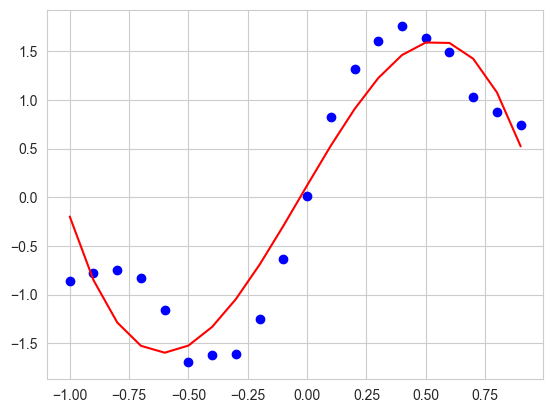

In [47]:
y_pred = model_a(x, w)
plt.scatter(x=x, y=Y, color='blue')
plt.plot(x, y_pred, color='red')
plt.show()